# 1D Finite Volume Method Simulation 

## import library

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## Setup Domain

In [7]:
L = 4   # Length of the domain
N = 400 # Number of grid points (increased for better resolution)

dx = L / N
print("Grid spacing (dx):", dx)

x = np.linspace(0, L, N, endpoint=False)

# Convection parameters
cfl   = 0.8
u_max = 1.0

# Diffusion parameters
alpha = 0.01
r     = 0.3   # stability limit is 0.5; use 0.3 for safety margin

dt_conv = cfl * dx / u_max
dt_diff = r * dx**2 / alpha

# Choose the smaller time step for stability
dt = min(dt_conv, dt_diff)
print("Time step size (dt):", dt)
print(f"  dt_conv = {dt_conv:.6f}  (CFL condition)")
print(f"  dt_diff = {dt_diff:.6f}  (diffusion condition)")

nt = 200
T  = nt * dt
print(f"Total simulation time (T): {T:.4f}")


Grid spacing (dx): 0.01
Time step size (dt): 0.003
  dt_conv = 0.008000  (CFL condition)
  dt_diff = 0.003000  (diffusion condition)
Total simulation time (T): 0.6000


## Initial Condition

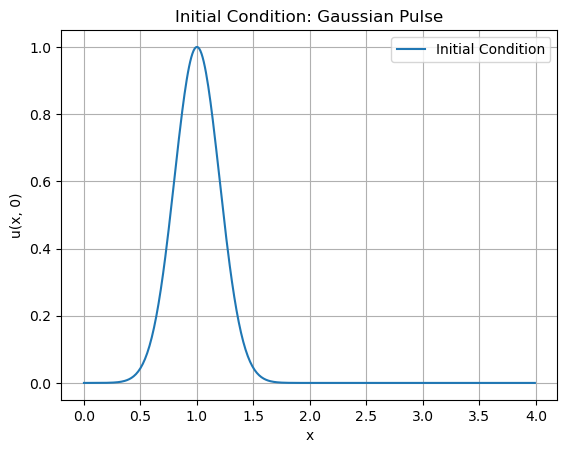

In [8]:
x0    = 1.0  # Initial position of the pulse
sigma = 0.2  # Width of the pulse (was 0.05 — too narrow, only 2.5 cells per sigma)

phi0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))
plt.plot(x, phi0, label='Initial Condition')
plt.title('Initial Condition: Gaussian Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()

## Solve FVM

In [9]:
def compute_convection_term(u, phi, dx):
    phi_left  = np.roll(phi,  1)   # phi_{P-1}
    phi_right = np.roll(phi, -1)   # phi_{P+1}

    # Upwind face reconstruction — general for any sign of u
    conv_flux_east = np.maximum(u, 0) * phi       + np.minimum(u, 0) * phi_right  # east face
    conv_flux_west = np.maximum(u, 0) * phi_left  + np.minimum(u, 0) * phi        # west face
    return (conv_flux_east - conv_flux_west) / dx

def compute_diffusion_term(phi, alpha, dx):
    diff_flux_east = alpha * (np.roll(phi, -1) - phi) / dx
    diff_flux_west = alpha * (phi - np.roll(phi, 1)) / dx
    return (diff_flux_east - diff_flux_west) / dx

def fvm_1d_scalar(phi, u, alpha, dx, dt):
    convection_term = compute_convection_term(u, phi, dx)
    diffusion_term  = compute_diffusion_term(phi, alpha, dx)
    return phi + dt * (-convection_term + diffusion_term)

phi = phi0.copy()
phi_history = [phi.copy()]
for n in range(nt):
    phi = fvm_1d_scalar(phi, u_max, alpha, dx, dt)
    phi_history.append(phi.copy())

# Conservation check — sum(phi)*dx should stay constant (total mass conserved)
mass_initial = np.sum(phi_history[0])  * dx
mass_final   = np.sum(phi_history[-1]) * dx
print(f"Total mass initial: {mass_initial:.10f}")
print(f"Total mass final:   {mass_final:.10f}")
print(f"Mass error:         {abs(mass_final - mass_initial):.2e}  ← should be ~machine precision")

Total mass initial: 0.5013255291
Total mass final:   0.5013255291
Mass error:         0.00e+00  ← should be ~machine precision


## Result

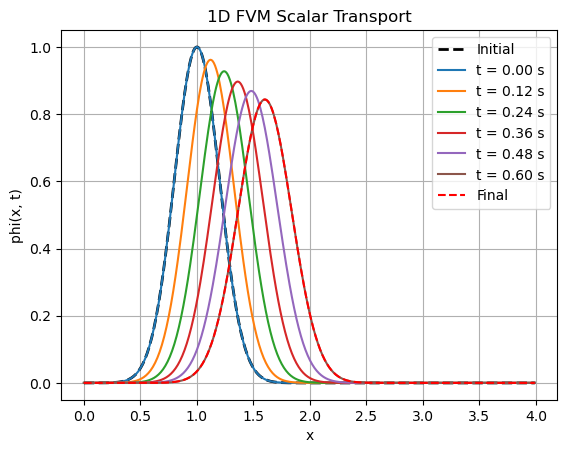

max phi at final time: 0.8435762171321514


In [10]:
plt.plot(x, phi_history[0], label='Initial', lw=2, ls='--', color='black')
for n in range(0, nt + 1, 40):
    plt.plot(x, phi_history[n], label=f't = {n*dt:.2f} s')
plt.plot(x, phi_history[-1], label='Final', linestyle='--', color='red')
plt.title('1D FVM Scalar Transport')
plt.xlabel('x')
plt.ylabel('phi(x, t)')
plt.legend()
plt.grid()
plt.show()

print("max phi at final time:", phi_history[-1].max())